<a href="https://colab.research.google.com/github/Judge252/-/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [43]:

dataset_train = pd.read_csv('Google_Stock_Price_Train.csv')
training_set = dataset_train.iloc[:, 1:2].values



In [44]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [45]:
X_train = []
y_train = []
for i in range (60, len(training_set_scaled)):
  X_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [46]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [47]:
X_train.shape

(1198, 60, 1)

In [48]:
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import Dense

In [49]:
regressor = Sequential()

In [50]:
regressor.add(LSTM(units = 50, return_sequences= True, input_shape = (X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [51]:
regressor.add(LSTM(units = 50, return_sequences= True))
regressor.add(Dropout(0.2))

In [52]:
regressor.add(LSTM(units = 50, return_sequences= True))
regressor.add(Dropout(0.2))

In [53]:
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))

In [54]:
regressor.add(Dense(units= 1))

In [55]:
regressor.compile(optimizer= 'adam', loss = 'mean_squared_error')

In [56]:
regressor.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 0.0345
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0145
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 0.0116
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0108
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.0094
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - loss: 0.0089
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0076
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 111ms/step - loss: 0.0079
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - loss: 0.0068
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.0064
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 0.0063
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0064
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - loss: 0.0060
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - loss: 0.0056
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 12

In [57]:
dataset_test = pd.read_csv('Google_Stock_Price_Test.csv')
real_stock_price = dataset_test.iloc[:, 1:2].values

In [58]:
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)
X_test = []
for i in range(60, 80):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step


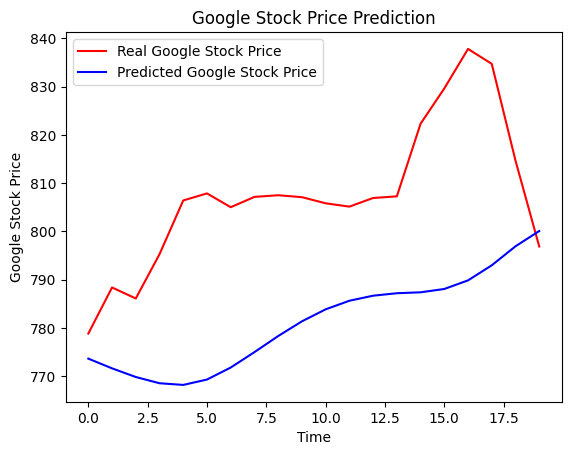

In [59]:
plt.plot(real_stock_price, color = 'red', label = 'Real Google Stock Price')
plt.plot(predicted_stock_price, color = 'blue', label = 'Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()